In [16]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

In [17]:
class QuadState(TypedDict) :
    
    a: int
    b: int
    c: int
    
    equation: str
    discriminant: float
    result: str 

In [18]:
def show_equation(state: QuadState):
    
    equation = f'{state["a"]}x2 + {state["b"]}x + {state["c"]}'
    
    return {'equation': equation}

In [19]:
def calculate_discriminant(state: QuadState):
    
    a = state['a']
    b = state['b']
    c = state['c']
    
    discriminant = b**2 - 4*a*c
    
    return {'discriminant': discriminant}

In [24]:
def real_roots(state: QuadState): 
    
    a = state['a']
    b = state['b']
    
    root1 = (-b + state['discriminant']**0.5)/(2*a)
    root2 = (-b - state['discriminant']**0.5)/(2*a)
    
    result = f'The roots are {root1} and {root2}'
    
    return {'result': result}

def equal_roots(state: QuadState): 
    
    a = state['a']
    b = state['b']
    
    root = (-b)/(2*a)
    
    result = f'The roots are {root}'
    
    return {'result': result}

def no_real_roots(state: QuadState): 
    
    result = f'No real roots'
    
    return {'result': result}

In [25]:
def check_conditions(state: QuadState) -> Literal["real_roots", "equal_roots", "no_real_roots"]:
    
    d = state['discriminant']
    
    if(d>0):
        return "real_roots"
    elif(d==0):
        return "equal_roots"
    else:
        return "no_real_roots"

In [26]:
graph = StateGraph(QuadState)

graph.add_node('show_equation', show_equation)
graph.add_node('calculate_discriminant', calculate_discriminant)
graph.add_node('real_roots', real_roots)
graph.add_node('equal_roots', equal_roots)
graph.add_node('no_real_roots', no_real_roots)

graph.add_edge(START, 'show_equation')
graph.add_edge('show_equation', 'calculate_discriminant')

graph.add_conditional_edges('calculate_discriminant', check_conditions)
graph.add_edge('real_roots', END)
graph.add_edge('equal_roots', END)
graph.add_edge('no_real_roots', END)

workflow = graph.compile()

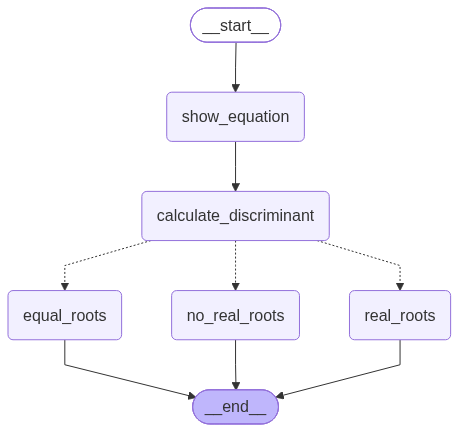

In [27]:
workflow

In [28]:
initial_state = {
    'a': 4,
    'b': -5,
    'c': -4
}

workflow.invoke(initial_state)

{'a': 4,
 'b': -5,
 'c': -4,
 'equation': '4x2 + -5x + -4',
 'discriminant': 89,
 'result': 'The roots are 1.8042476415070754 and -0.5542476415070754'}